# Modellierung

Wir untersuchen gemeinsame Veranstaltungstage von Athleten und gemeinsame Disziplinen in ihren Bestleistungen. Grundlage sind alle Jahre des bereinigten Datensatzes, Männer und Frauen gemeinsam.

| Netzwerk | Knoten | Verbindung und Gewicht |
| --- | --- | --- |
| Bipartites Hauptmodell | Athleten und Veranstaltungstage | Mindestens eine Bestleistung des Athleten an diesem Tag |
| Athletennetzwerk | Athleten | Gewicht zählt verschiedene gemeinsame Veranstaltungstage |
| Disziplinennetzwerk | Disziplin und Beckenlänge | Gewicht zählt verschiedene gemeinsame Athleten |

Wir bereiten die Zuordnungen vor, erstellen und prüfen die Netzwerke und zeigen drei Abbildungen. Anschliessend speichern wir die Netzwerkdaten für die weiteren Kapitel.

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data/processed/athlete_data_clean.parquet'
OUTPUT_DIR = PROJECT_ROOT / 'data/processed/networks'
SEED = 42

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
GENDER_COLORS = {'female': '#cb7140', 'male': '#367da2'}
df = pd.read_parquet(DATA_PATH)

## 1. Datengrundlage und Zuordnungen

Ein Veranstaltungstag besteht aus Wettkampfname, Ort, Datum und Beckenlänge. Wir vereinheitlichen Leerzeichen und behalten gekürzte Namen bei. Fehlende Angaben und Unknown verhindern die Tageszuordnung. Zwischenzeiten mit Lap bleiben für das Hauptmodell verwendbar.

In [2]:
event_key = ['best_name', 'city', 'best_date', 'course']
records = df[['athlete_id', *event_key]].copy()
for column in ['best_name', 'city', 'course']:
    records[column] = records[column].str.replace(r'\s+', ' ', regex=True).str.strip()

valid_event = records[event_key].notna().all(axis=1)
for column in ['best_name', 'city', 'course']:
    valid_event &= ~records[column].str.casefold().isin(['', 'unknown'])

athlete_events = (
    records.loc[valid_event].drop_duplicates()
    .sort_values([*event_key, 'athlete_id']).reset_index(drop=True)
)
athlete_events['event_id'] = (
    'event_' + athlete_events.groupby(event_key, sort=True).ngroup().astype(str)
)
athlete_events['athlete_node'] = 'athlete_' + athlete_events['athlete_id'].astype(str)
events = athlete_events.drop_duplicates('event_id').set_index('event_id')[event_key]

athlete_columns = ['athlete_id', 'athlete_name', 'gender', 'athlete_nation',
                   'athlete_date', 'club']
athletes = (
    df[athlete_columns].drop_duplicates('athlete_id')
    .rename(columns={'athlete_date': 'birth_year'})
    .sort_values('athlete_id')
)
athletes['athlete_node'] = 'athlete_' + athletes['athlete_id'].astype(str)
athletes = athletes.set_index('athlete_node')
missing_event_athletes = athletes.loc[
    ~athletes.index.isin(athlete_events['athlete_node'])
]

display(pd.Series({
    'Bereinigte Bestleistungseinträge': len(df),
    'Ohne vollständige Veranstaltungsangaben': int((~valid_event).sum()),
    'Athleten ohne zuordenbaren Veranstaltungstag': len(missing_event_athletes),
    'Athleten im Hauptmodell': athlete_events['athlete_id'].nunique(),
    'Veranstaltungstage': len(events),
    'Eindeutige Zuordnungen': len(athlete_events),
}, name='Anzahl').to_frame())

,Anzahl
Bereinigte Bestleistungseinträge,285173
Ohne vollständige Veranstaltungsangaben,854
Athleten ohne zuordenbaren Veranstaltungstag,6
Athleten im Hauptmodell,13156
Veranstaltungstage,62946
Eindeutige Zuordnungen,238942


In [3]:
# Verschiedene Namen an sonst gleichen Athletentagen sichtbar machen.
same_day = ['athlete_id', 'city', 'best_date', 'course']
name_variants = (
    athlete_events.groupby(same_day)['best_name']
    .agg(lambda names: tuple(sorted(set(names))))
    .loc[lambda names: names.map(len) > 1]
)
print(f'{len(name_variants)} Athletentage mit mehreren gespeicherten Wettkampfnamen.')
with pd.option_context('display.max_colwidth', None):
    display(name_variants.head(3).rename('Gespeicherte Namen').to_frame())

65 Athletentage mit mehreren gespeicherten Wettkampfnamen.


Gespeicherte Namen
athlete_id city                  best_date  course                                                                      
4013807    Sault Ste. Marie (ON) 2009-02-07 25m     (Dave Kensit Memorial Championship ..., Dave Kensit Senior Team ...)
           Sudbury (ON)          2010-06-12 50m         (Dr. Jeno Tihanyi A and Senior ..., Dr. Jeno Tihanyi Senior ...)
4042491    Federal Way (USA)     2006-04-01 50m                         (US Spring Championships, US Spring Time Trials)

Unterschiedliche Namen können verschiedene Veranstaltungen oder abweichende Bezeichnungen meinen. Wir lassen sie getrennt. Dadurch könnten Zusammenhänge unentdeckt bleiben. Die sechs Athleten ohne zuordenbaren Tag werden nur im Hauptmodell ausgelassen.

## 2. Hauptmodell und gewichtete Projektion

Eine Verbindung zwischen Athlet und Veranstaltungstag wird einmal angelegt. Die gewichtete Projektion zählt gemeinsame Nachbarn, hier Veranstaltungstage.

In [4]:
def add_table_nodes(graph, table, node_type):
    """Tabellenattribute übernehmen, fehlende Werte auslassen und Daten als ISO speichern."""
    for node, row in table.to_dict(orient='index').items():
        attributes = {
            key: value.isoformat() if isinstance(value, pd.Timestamp) else value
            for key, value in row.items() if pd.notna(value)
        }
        graph.add_node(node, node_type=node_type, **attributes)


athletes['label'] = athletes['athlete_name']
events['label'] = (
    events['best_name'] + ' | ' + events['city'] + ' | '
    + events['best_date'].dt.strftime('%d.%m.%Y') + ' | ' + events['course']
)
athlete_nodes = sorted(athlete_events['athlete_node'].unique())

event_graph = nx.Graph(name='Athleten und Veranstaltungstage')
add_table_nodes(event_graph, athletes.loc[athlete_nodes], 'athlete')
add_table_nodes(event_graph, events, 'event')
event_graph.add_edges_from(
    athlete_events[['athlete_node', 'event_id']].itertuples(index=False, name=None)
)

athlete_graph = nx.bipartite.weighted_projected_graph(event_graph, athlete_nodes)
athlete_graph.graph['name'] = 'Athleten über gemeinsame Veranstaltungstage'

In [5]:
# Zwei reale Veranstaltungstage für das spätere Projektionsbeispiel.
example_dates = pd.to_datetime(['2017-12-02', '2018-12-01'])
example_events = events.index[
    events['best_name'].isin(['"Kup Novi Grad 2017"', '"Kup Novi Grad 2018"'])
    & events['city'].eq('Sarajevo')
    & events['best_date'].isin(example_dates)
    & events['course'].eq('25m')
].tolist()
assert len(example_events) == 2

common_athletes = sorted(
    set(event_graph[example_events[0]]) & set(event_graph[example_events[1]])
)
example_pair = common_athletes[:2]
common_days = sorted(
    set(event_graph[example_pair[0]]) & set(event_graph[example_pair[1]])
)
pair_names = athletes.loc[example_pair, 'athlete_name'].tolist()
print(f'{pair_names[0]} und {pair_names[1]}: '
      f'Gewicht {athlete_graph.edges[example_pair]["weight"]}.')
display(events.loc[common_days, event_key].reset_index(drop=True))

MESIC, Hena und GEC, Ersin: Gewicht 7.


,best_name,city,best_date,course
0,"""Kup Novi Grad 2017""",Sarajevo,2017-12-02,25m
1,"""Kup Novi Grad 2018""",Sarajevo,2018-12-01,25m
2,Otvoreno prvenstvo BiH,Sarajevo,2018-12-29,25m
3,Otvoreno prvenstvo BiH 25m,Sarajevo,2017-12-30,25m
4,Susret Reprezentacija ...,Beograd (SRB),2018-03-18,50m
5,XXII. Montenegro Mimosa Cup,Herceg Novi (MNE),2017-02-18,25m
6,Zimsko Prvenstvo Bih,Sarajevo,2018-03-10,50m


## 3. Disziplinennetzwerk

Strecke, Schwimmstil und Beckenlänge bilden einen Knoten. Jede Person zählt je Kombination einmal. Wir schliessen Lap aus und behalten alle seltenen Disziplinen. Eine gemeinsame Veranstaltung ist für diese Verbindungen nicht erforderlich.

In [6]:
athlete_disciplines = (
    df.loc[~df['event'].str.endswith(' Lap'), ['athlete_id', 'event', 'course']]
    .drop_duplicates().sort_values(['event', 'course', 'athlete_id'])
    .reset_index(drop=True)
)
disciplines = (
    athlete_disciplines[['event', 'course']].drop_duplicates()
    .sort_values(['event', 'course']).reset_index(drop=True)
)
discipline_parts = disciplines['event'].str.extract(r'^(\d+)m (.+)$')
assert discipline_parts.notna().all().all()
disciplines['distance_m'] = discipline_parts[0].astype(int)
disciplines['stroke'] = discipline_parts[1]
disciplines['discipline_id'] = 'discipline_' + disciplines.index.astype(str)
athlete_disciplines = athlete_disciplines.merge(
    disciplines[['event', 'course', 'discipline_id']],
    on=['event', 'course'], validate='many_to_one',
)
athlete_disciplines['athlete_node'] = (
    'athlete_' + athlete_disciplines['athlete_id'].astype(str)
)
disciplines = disciplines.set_index('discipline_id')
disciplines['n_athletes'] = (
    athlete_disciplines.groupby('discipline_id')['athlete_id'].nunique()
)
disciplines['label'] = disciplines['event'] + ' | ' + disciplines['course']

discipline_membership = nx.Graph()
add_table_nodes(discipline_membership, disciplines, 'discipline')
discipline_membership.add_edges_from(
    athlete_disciplines[['athlete_node', 'discipline_id']]
    .itertuples(index=False, name=None)
)
discipline_graph = nx.bipartite.weighted_projected_graph(
    discipline_membership, disciplines.index.tolist()
)
discipline_graph.graph['name'] = 'Disziplinen über gemeinsame Athleten'

In [7]:
example_disciplines = disciplines.index[
    disciplines['event'].isin(['100m Freestyle', '200m Freestyle'])
    & disciplines['course'].eq('50m')
].tolist()
shared_swimmers = (
    set(discipline_membership[example_disciplines[0]])
    & set(discipline_membership[example_disciplines[1]])
)
display(disciplines.loc[
    example_disciplines, ['event', 'course', 'n_athletes']
].reset_index(drop=True))
print('Gemeinsame Athleten und Kantengewicht:', len(shared_swimmers))

,event,course,n_athletes
0,100m Freestyle,50m,10060
1,200m Freestyle,50m,9312


Gemeinsame Athleten und Kantengewicht: 8503


## 4. Prüfung und Übersicht

Wir prüfen die Knotentypen, Mehrfachzählungen und ausgewählte Gewichte. Die Summe aller Athletengewichte muss ausserdem der Anzahl aller Athletenpaare je Veranstaltungstag entsprechen.

In [8]:
assert nx.is_bipartite(event_graph)
assert set(athlete_graph) == set(athlete_nodes)
assert event_graph.number_of_edges() == len(athlete_events)
assert not athlete_events.duplicated(['athlete_id', 'event_id']).any()
assert not athlete_disciplines.duplicated(['athlete_id', 'discipline_id']).any()

for graph in [athlete_graph, discipline_graph]:
    assert nx.number_of_selfloops(graph) == 0
    assert all(data['weight'] > 0 and float(data['weight']).is_integer()
               for _, _, data in graph.edges(data=True))

event_sizes = athlete_events.groupby('event_id').size()
assert sum(nx.get_edge_attributes(athlete_graph, 'weight').values()) == int(
    (event_sizes * (event_sizes - 1) // 2).sum()
)
assert athlete_graph.edges[example_pair]['weight'] == len(common_days)
assert discipline_graph.edges[example_disciplines]['weight'] == len(shared_swimmers)

rng = np.random.default_rng(SEED)
eligible_athletes = [node for node in athlete_nodes if athlete_graph.degree(node)]
for node in rng.choice(eligible_athletes, size=5, replace=False):
    neighbor = sorted(athlete_graph[node])[0]
    expected_weight = len(set(event_graph[node]) & set(event_graph[neighbor]))
    assert athlete_graph[node][neighbor]['weight'] == expected_weight

networks = {
    'Bipartites Hauptmodell': event_graph,
    'Athletennetzwerk': athlete_graph,
    'Disziplinennetzwerk': discipline_graph,
}
display(pd.DataFrame([
    {'Netzwerk': name, 'Knoten': graph.number_of_nodes(),
     'Kanten': graph.number_of_edges(),
     'Isolierte Knoten': len(list(nx.isolates(graph)))}
    for name, graph in networks.items()
]).set_index('Netzwerk'))
print('Prüfungen bestanden.')

,Knoten,Kanten,Isolierte Knoten
Netzwerk,,,
Bipartites Hauptmodell,76102,238942,0
Athletennetzwerk,13156,1231245,20
Disziplinennetzwerk,78,2265,0


Prüfungen bestanden.


## 5. Darstellungen

### Hauptmodell und Projektion im Ausschnitt

Wir zeigen zwei Veranstaltungstage in Sarajevo. Die Gewichte rechts beziehen sich ausschliesslich auf diese beiden Tage. Im vollständigen Athletennetzwerk können weitere gemeinsame Tage hinzukommen. Unbeschriftete Kanten rechts haben Gewicht 1.

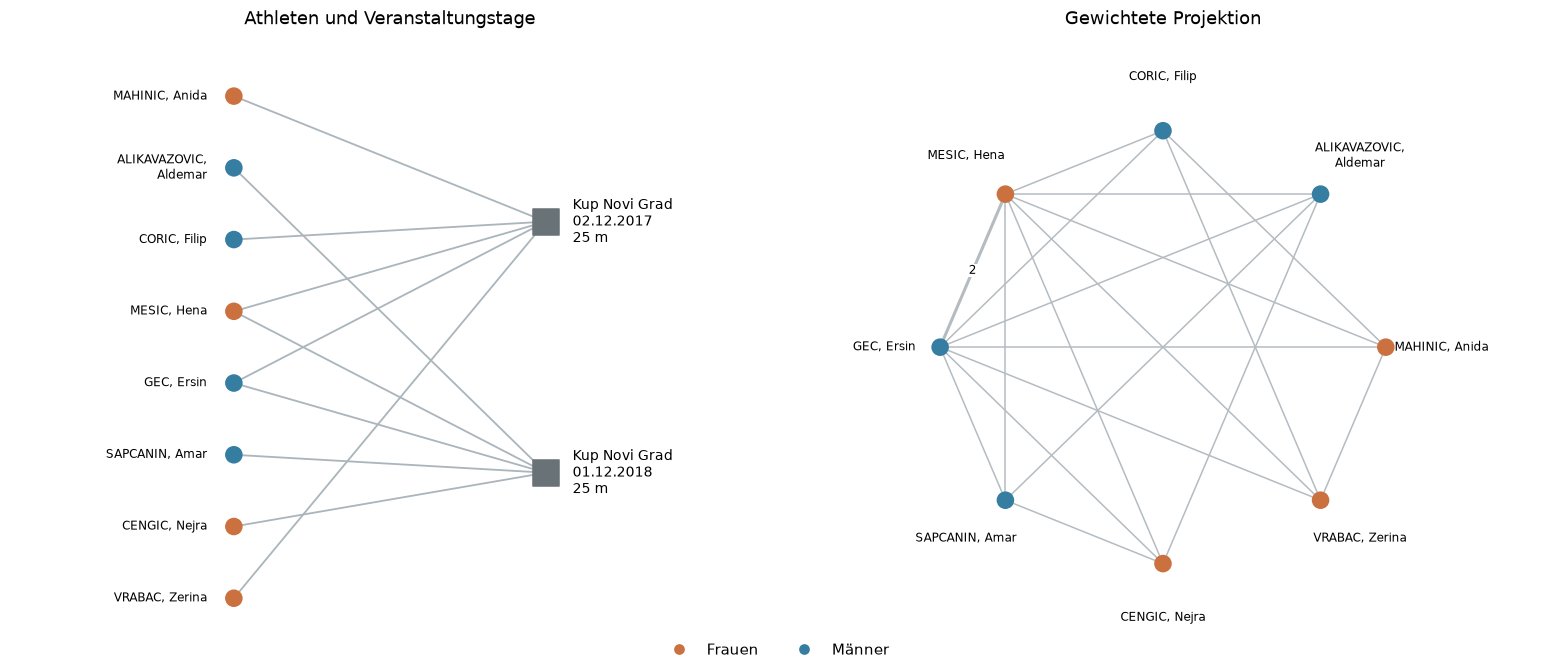

In [9]:
example_athletes = sorted({
    node for event in example_events for node in event_graph[event]
})
example_bipartite = event_graph.subgraph(example_athletes + example_events)
example_projection = nx.bipartite.weighted_projected_graph(
    example_bipartite, example_athletes
)
athlete_labels = {
    node: fill(athletes.loc[node, 'athlete_name'], width=18)
    for node in example_athletes
}
event_labels = {
    node: f'Kup Novi Grad\n{events.loc[node, "best_date"]:%d.%m.%Y}\n25 m'
    for node in example_events
}
bipartite_positions = {
    node: (0, y) for node, y in zip(example_athletes, np.linspace(1, -1, len(example_athletes)))
}
bipartite_positions.update(dict(zip(example_events, [(1.4, 0.5), (1.4, -0.5)])))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')
nx.draw_networkx_edges(example_bipartite, bipartite_positions, ax=axes[0],
                       edge_color='#abb5bc', width=1.2)
nx.draw_networkx_nodes(example_bipartite, bipartite_positions, ax=axes[0],
                       nodelist=example_athletes, node_size=110,
                       node_color=[GENDER_COLORS[athletes.loc[n, 'gender']]
                                   for n in example_athletes])
nx.draw_networkx_nodes(example_bipartite, bipartite_positions, ax=axes[0],
                       nodelist=example_events, node_size=300,
                       node_shape='s', node_color='#697277')
for node, label in athlete_labels.items():
    x, y = bipartite_positions[node]
    axes[0].text(x - 0.12, y, label, ha='right', va='center', fontsize=8)
for node, label in event_labels.items():
    x, y = bipartite_positions[node]
    axes[0].text(x + 0.12, y, label, ha='left', va='center', fontsize=9)
axes[0].set(xlim=(-1, 2.4), ylim=(-1.25, 1.25), title='Athleten und Veranstaltungstage')

projection_positions = nx.circular_layout(example_projection)
nx.draw_networkx_edges(
    example_projection, projection_positions, ax=axes[1], edge_color='#b4bcc2',
    width=[data['weight'] for _, _, data in example_projection.edges(data=True)],
)
nx.draw_networkx_nodes(example_projection, projection_positions, ax=axes[1],
                       nodelist=example_athletes, node_size=110,
                       node_color=[GENDER_COLORS[athletes.loc[n, 'gender']]
                                   for n in example_athletes])
nx.draw_networkx_edge_labels(
    example_projection, projection_positions, ax=axes[1], font_size=8,
    edge_labels={(u, v): data['weight'] for u, v, data in example_projection.edges(data=True)
                 if data['weight'] > 1},
    rotate=False, bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 0.3},
)
nx.draw_networkx_labels(
    example_projection,
    {node: 1.25 * position for node, position in projection_positions.items()},
    labels=athlete_labels, ax=axes[1], font_size=8,
)
axes[1].set(xlim=(-1.7, 1.7), ylim=(-1.45, 1.45), title='Gewichtete Projektion')
for ax in axes:
    ax.set_axis_off()
fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=GENDER_COLORS[gender], label=label)
    for gender, label in [('female', 'Frauen'), ('male', 'Männer')]
], loc='lower center', ncol=2, frameon=False)
plt.show()

### Gesamtansicht des Athletennetzwerks

Die Gesamtansicht enthält alle Knoten und Kanten, einschliesslich isolierter Athleten. Ein Federlayout ordnet die Knoten an, die Farbe zeigt das Geschlecht. Die dichte Überlagerung begrenzt, was sich in dieser Übersicht erkennen lässt.

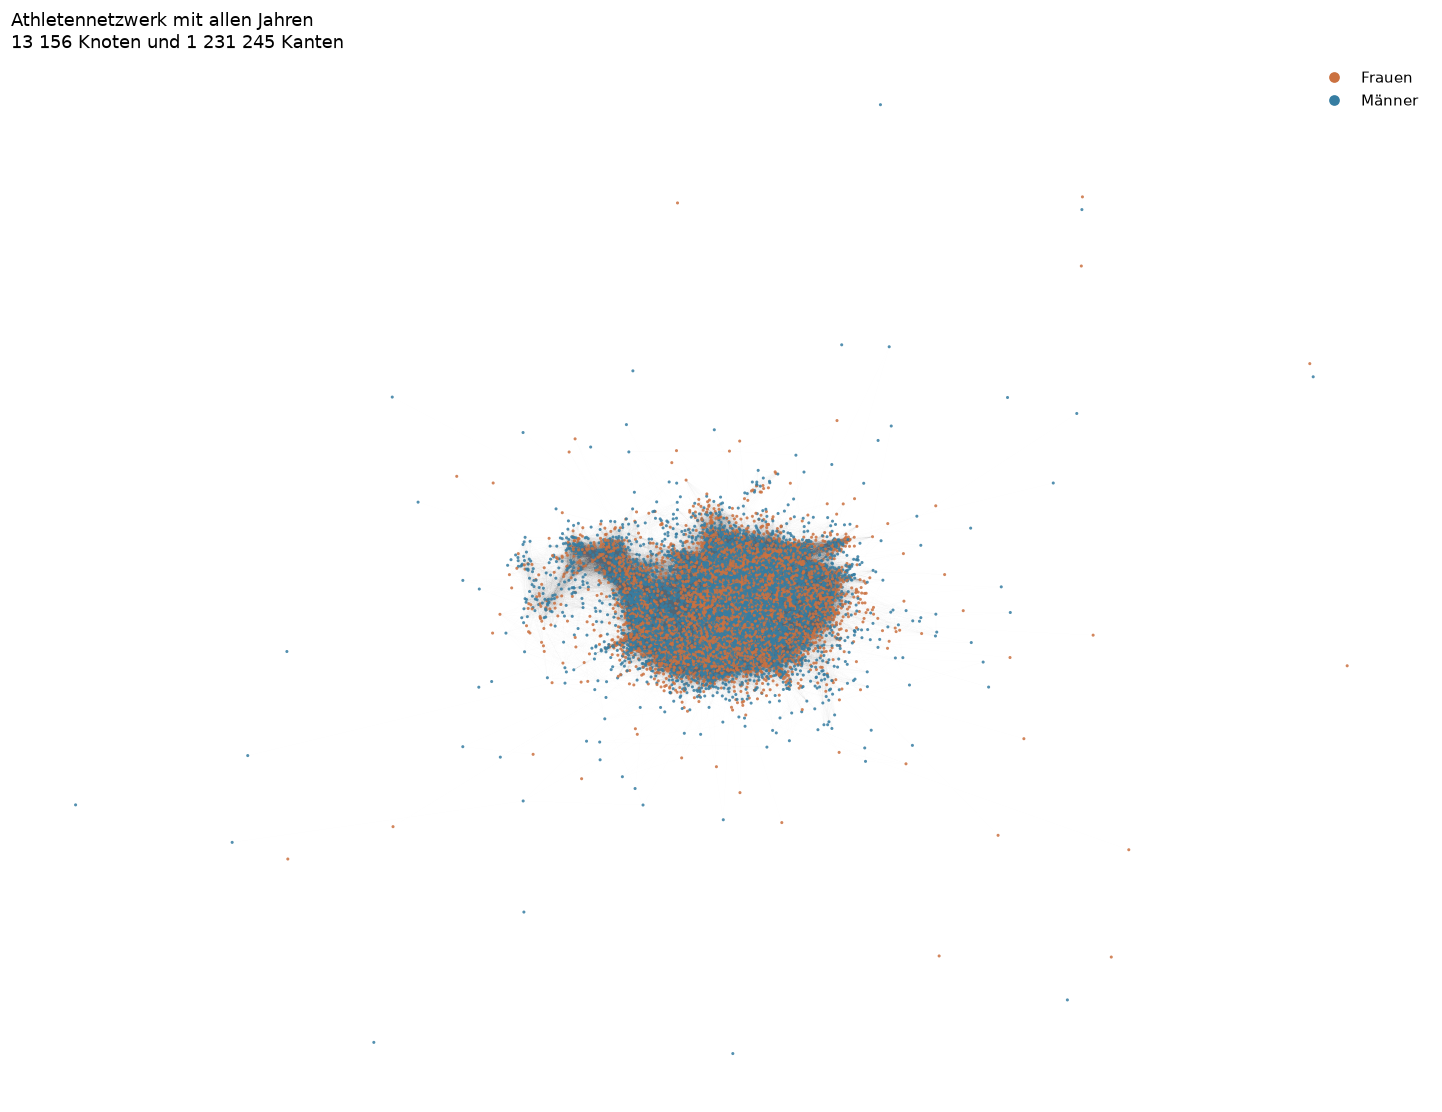

In [10]:
overall_positions = nx.spring_layout(
    athlete_graph, seed=SEED, iterations=30, weight='weight', method='energy'
)

fig, ax = plt.subplots(figsize=(13, 10), layout='constrained')
nx.draw_networkx_edges(athlete_graph, overall_positions, ax=ax,
                       width=0.08, alpha=0.018, edge_color='#526675')
nx.draw_networkx_nodes(
    athlete_graph, overall_positions, ax=ax, nodelist=athlete_nodes,
    node_size=4, linewidths=0, alpha=0.85,
    node_color=[GENDER_COLORS[athletes.loc[node, 'gender']] for node in athlete_nodes],
)
ax.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=GENDER_COLORS[gender], label=label)
    for gender, label in [('female', 'Frauen'), ('male', 'Männer')]
], loc='upper right', frameon=False)
ax.set_title(
    f'Athletennetzwerk mit allen Jahren\n'
    f'{len(athlete_graph):,} Knoten und {athlete_graph.number_of_edges():,} Kanten'.replace(',', ' '),
    loc='left',
)
ax.set_axis_off()
plt.show()

### Disziplinen und Beckenlängen

Alle 78 Knoten sind nach Schwimmstil und Strecke am Kreis angeordnet. Die Beschriftung zeigt Strecke und Beckenlänge. Grössere Knoten stehen für mehr Athleten, kräftigere Kanten für mehr gemeinsame Athleten. Die Farben kennzeichnen Schwimmstile.

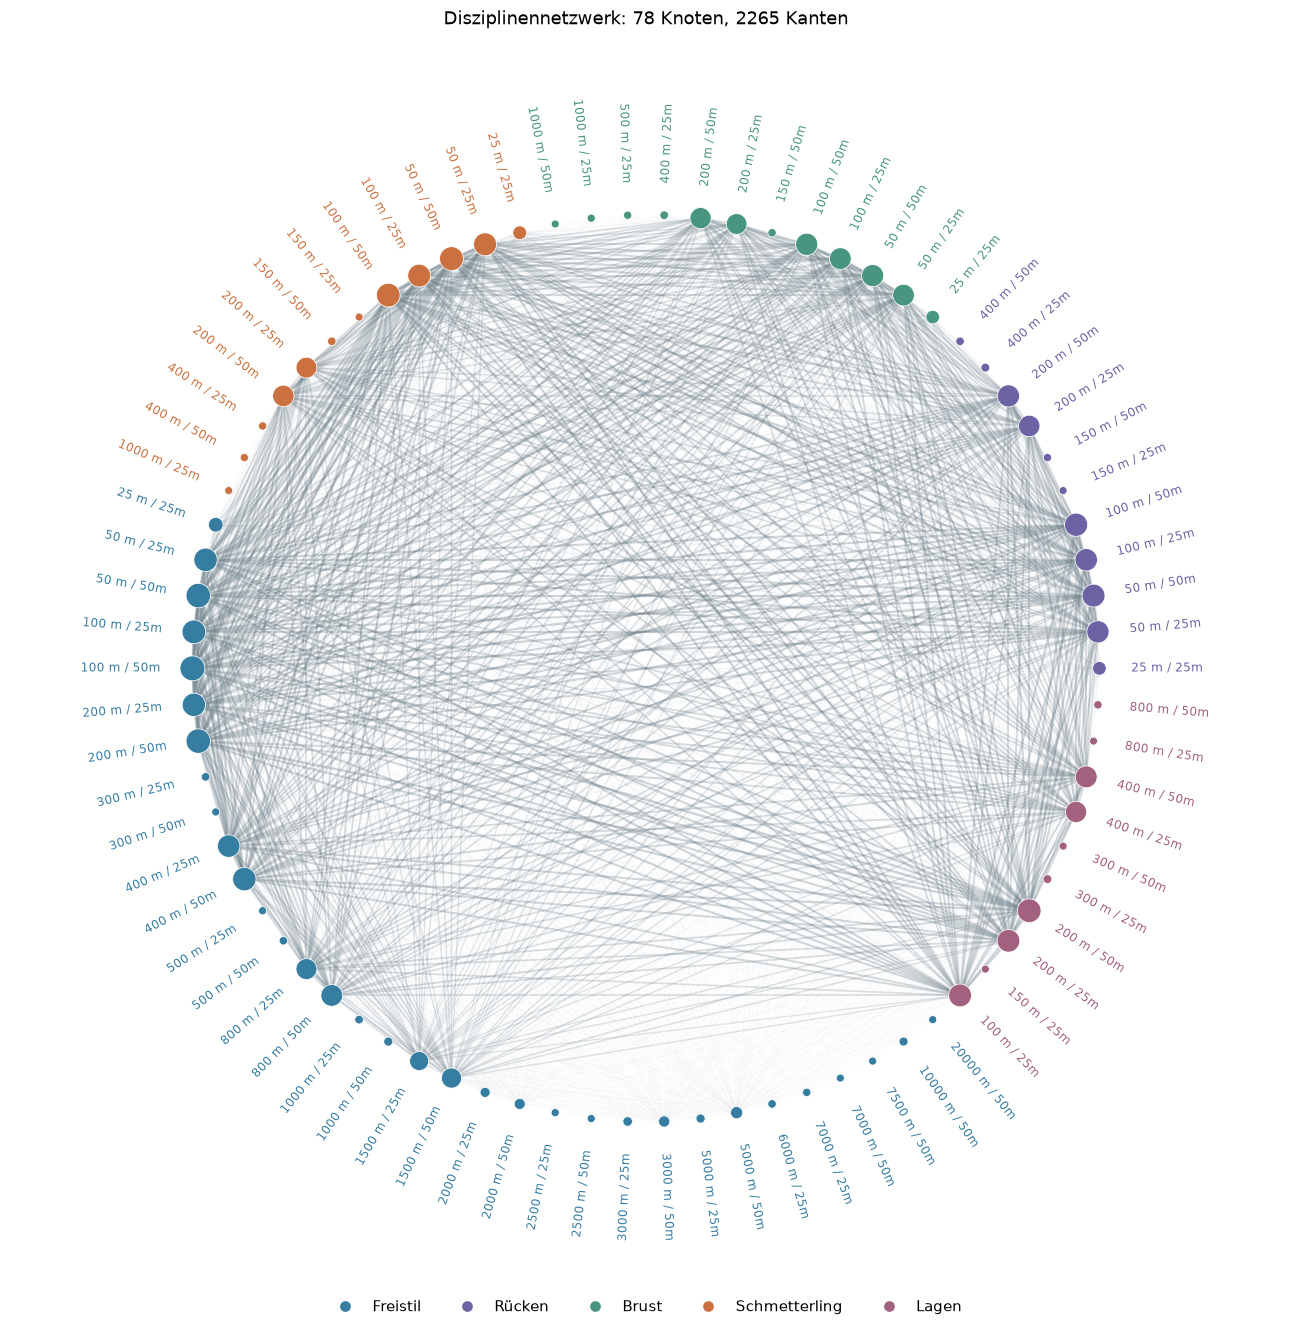

In [11]:
stroke_colors = {
    'Freestyle': '#367da2', 'Backstroke': '#6b63a3', 'Breaststroke': '#489580',
    'Butterfly': '#cb7140', 'Medley': '#a36180',
}
stroke_labels = {
    'Freestyle': 'Freistil', 'Backstroke': 'Rücken', 'Breaststroke': 'Brust',
    'Butterfly': 'Schmetterling', 'Medley': 'Lagen',
}
ordered_disciplines = disciplines.sort_values(
    ['stroke', 'distance_m', 'course']
).index.tolist()
angles = np.linspace(0, 2 * np.pi, len(ordered_disciplines), endpoint=False)
discipline_positions = {
    node: np.array([np.cos(angle), np.sin(angle)])
    for node, angle in zip(ordered_disciplines, angles)
}
weights = np.array([data['weight'] for _, _, data in discipline_graph.edges(data=True)])
relative_weight = np.sqrt(weights / weights.max())

fig, ax = plt.subplots(figsize=(12, 12), layout='constrained')
nx.draw_networkx_edges(
    discipline_graph, discipline_positions, ax=ax,
    width=0.1 + 1.6 * relative_weight, alpha=0.02 + 0.35 * relative_weight,
    edge_color='#697c87',
)
nx.draw_networkx_nodes(
    discipline_graph, discipline_positions, ax=ax, nodelist=ordered_disciplines,
    node_color=[stroke_colors[disciplines.loc[n, 'stroke']] for n in ordered_disciplines],
    node_size=25 + 240 * np.sqrt(
        disciplines.loc[ordered_disciplines, 'n_athletes'] / disciplines['n_athletes'].max()
    ),
    edgecolors='white', linewidths=0.5,
)
for node, angle in zip(ordered_disciplines, angles):
    x, y = 1.07 * discipline_positions[node]
    rotation = np.degrees(angle)
    on_left = np.cos(angle) < 0
    ax.text(
        x, y, f'{disciplines.loc[node, "distance_m"]} m / {disciplines.loc[node, "course"]}',
        rotation=rotation + (180 if on_left else 0), rotation_mode='anchor',
        ha='right' if on_left else 'left', va='center', fontsize=8,
        color=stroke_colors[disciplines.loc[node, 'stroke']],
    )
ax.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=color, label=stroke_labels[stroke])
    for stroke, color in stroke_colors.items()
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=False)
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect='equal',
       title=f'Disziplinennetzwerk: {len(discipline_graph)} Knoten, '
             f'{discipline_graph.number_of_edges()} Kanten')
ax.set_axis_off()
plt.show()

## 6. Netzwerkdaten speichern

GEXF speichert die Graphen mit ihren Attributen für Python und Gephi. Die Parquet Tabellen bewahren die eindeutigen Zuordnungen mit den ursprünglichen Athletenkennungen.

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for filename, graph in [
    ('athlete_events.gexf', event_graph),
    ('athletes.gexf', athlete_graph),
    ('disciplines.gexf', discipline_graph),
]:
    nx.write_gexf(graph, OUTPUT_DIR / filename, prettyprint=False)

athlete_events.to_parquet(OUTPUT_DIR / 'athlete_events.parquet', index=False)
athlete_disciplines.to_parquet(OUTPUT_DIR / 'athlete_disciplines.parquet', index=False)
print('Drei Netzwerke und zwei Zuordnungstabellen gespeichert.')

Drei Netzwerke und zwei Zuordnungstabellen gespeichert.


## 7. Einordnung

Das Hauptnetzwerk verbindet Athleten über Veranstaltungstage ihrer gespeicherten Bestleistungen. Das Zusatznetzwerk beschreibt Disziplinen, die bei denselben Athleten vorkommen. Beides sind beobachtete Zusammenhänge im ausgewählten Datensatz.

Bestleistungen ersetzen keine vollständigen Teilnehmerlisten und belegen keine persönliche Bekanntschaft. Unterschiedlich bezeichnete Veranstaltungen können getrennt bleiben, während identische gekürzte Bezeichnungen Verwechslungen ermöglichen. Im Disziplinennetzwerk sind 29 der 78 Kombinationen bei weniger als zehn Athleten belegt.

Die Modelle und Abbildungen bilden die Grundlage für die anschliessenden Analysen.